<a href="https://colab.research.google.com/github/marmalux/Telecom-X-Machine-Learning/blob/main/Churn_de_clientes_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predición de cancelación de churn de clientes Telecom X

## Importar bibliotecas - general

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Importar datos

Se importaran datos del proyecto de anáslisis de Telecom X los cuales ya estan limpiados para poder iniciar con la etapa de tratar datos pero para el modelo predictivo.

Además se elimina la columna ID

In [2]:
url_api ="https://github.com/marmalux/Telecom-X-Machine-Learning/raw/refs/heads/main/datos_tratados_Telecom_X.csv"

datos = pd.read_csv(url_api)
datos = datos.drop(['customerID'],axis=1)
datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total,Charges_Day,Services_Number
0,0,Female,0,1,1,9,1,No,DSL,No,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,2


## Correlación  

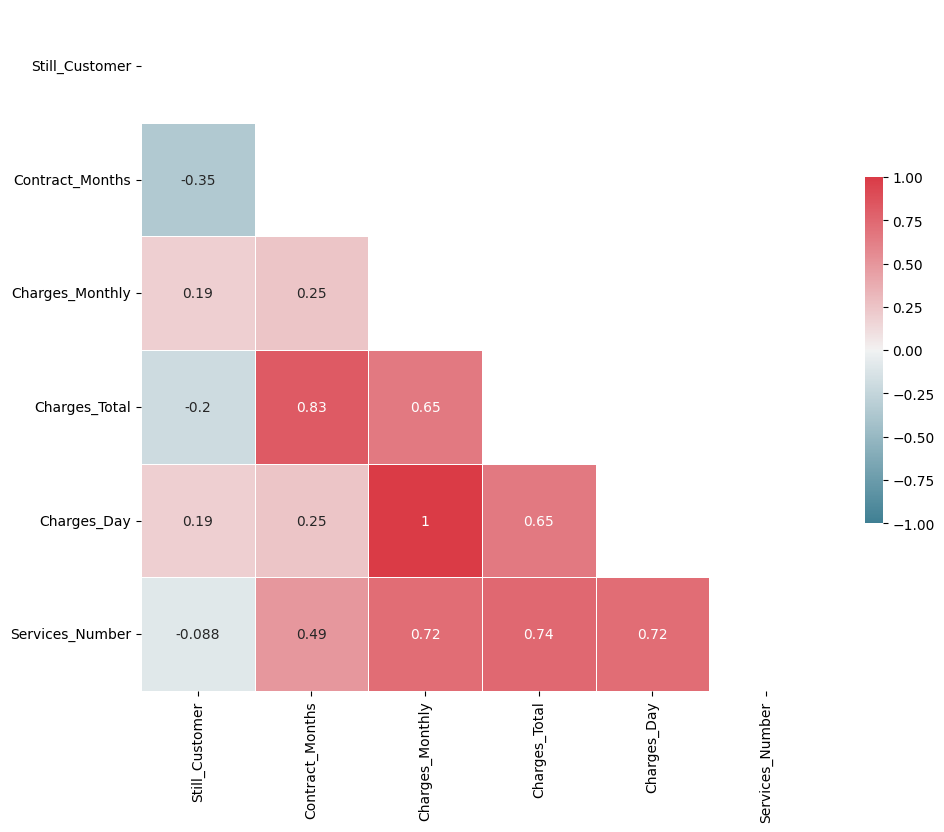

In [3]:
corr = datos[['Still_Customer','Contract_Months','Charges_Monthly','Charges_Total','Charges_Day','Services_Number']].corr()

# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

plt.show()

A partir de esta pequeña correlacion se puede ver que las columnas 'Charges_Monthly', 'Charges_Day', 'Charges_Total' tienen una relacion mas directa que pueden perjudicar al modelo por lo que solo se deja uno de ellos, además, 'Services_Number' tambien puede perjudicar al modelo pues surge a partir de los servicios mostrados, por lo que tambien se elimina

In [4]:
datos = datos.drop(['Charges_Monthly','Charges_Day','Services_Number'], axis=1)
datos.head(4)

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,593.30
1,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,542.40
2,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,280.85
3,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,1237.85


### Mapear datos para modelo

Columnas como 'Online_Security' tiene un valor extra 'No internet service' que no se necesita debido a que esto depende mas de la columna 'Internet_Service' asi que se puede quitar este valor para dejarlo como 'Yes' y 'No' para intentar mejorar el modelo

In [5]:
len('')

0

In [6]:
columnas = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies']

# se usan columnas que tengan mas que 'yes' y 'no'
for col in columnas:
# for col in columnas_binarias:
    datos[col] = datos[col].replace({"No internet service":"No","No phone service":"No"})
    datos[col] = datos[col].map({"Yes":1,"No":0})

columnas = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
            'Still_Customer','Partner', 'Dependents','Paperless_Billing']

# for columna in columnas:
#   datos[columna] = datos[columna].astype(np.int64)
datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,267.40


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Still_Customer     7043 non-null   int64  
 1   Gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Contract_Months    7043 non-null   int64  
 6   Phone_Service      7043 non-null   int64  
 7   Multiple_Lines     7043 non-null   int64  
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   int64  
 10  Online_Backup      7043 non-null   int64  
 11  Device_Protection  7043 non-null   int64  
 12  Tech_Support       7043 non-null   int64  
 13  Streaming_TV       7043 non-null   int64  
 14  Streaming_Movies   7043 non-null   int64  
 15  Contract_type      7043 non-null   object 
 16  Paperless_Billing  7043 

## Distribución churn clientes

In [8]:
estadisticas_columnas=datos.describe() # se almacena el dataframe en una variable para poder usar estos datos despues
datos.describe()

,Still_Customer,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Paperless_Billing,Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,2279.734304
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,398.550000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1394.550000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8684.800000


In [9]:
porcentaje_churn = estadisticas_columnas.loc['mean','Still_Customer']

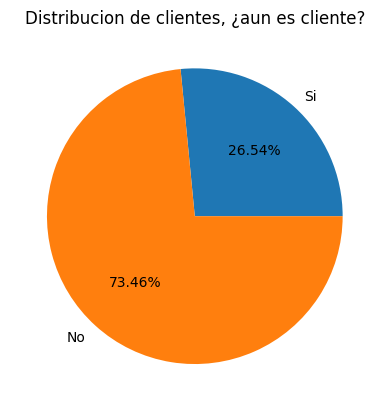

In [10]:
porcentaje_churn = estadisticas_columnas.loc['mean','Still_Customer']

fig, ax=plt.subplots()
ax.pie(x=[porcentaje_churn,1-porcentaje_churn],labels=['Si','No'],autopct='%0.2f%%')
ax.set_title('Distribucion de clientes, ¿aun es cliente?')
plt.show()
fig.savefig('distribucion_clientes.png')

## Encoding

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer   #para aplicar propiedades especificas a columnas especificas

categoricas = ['Gender','Internet_Service','Contract_type','Payment_Method']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos = one_hot_enc.fit_transform(datos)    #ajusta el transformador de datos y luego transforma con fit_transform
datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())
datos

,onehotencoder__Gender_Female,onehotencoder__Gender_Male,onehotencoder__Internet_Service_DSL,onehotencoder__Internet_Service_Fiber optic,onehotencoder__Internet_Service_No,onehotencoder__Contract_type_Month-to-month,onehotencoder__Contract_type_One year,onehotencoder__Contract_type_Two year,onehotencoder__Payment_Method_Bank transfer (automatic),onehotencoder__Payment_Method_Credit card (automatic),...,remainder__Phone_Service,remainder__Multiple_Lines,remainder__Online_Security,remainder__Online_Backup,remainder__Device_Protection,remainder__Tech_Support,remainder__Streaming_TV,remainder__Streaming_Movies,remainder__Paperless_Billing,remainder__Charges_Total
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,593.30
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,542.40
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,280.85
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1237.85
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,742.90
7039,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1873.70
7040,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,92.75
7041,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4627.65


In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   onehotencoder__Gender_Female                             7043 non-null   float64
 1   onehotencoder__Gender_Male                               7043 non-null   float64
 2   onehotencoder__Internet_Service_DSL                      7043 non-null   float64
 3   onehotencoder__Internet_Service_Fiber optic              7043 non-null   float64
 4   onehotencoder__Internet_Service_No                       7043 non-null   float64
 5   onehotencoder__Contract_type_Month-to-month              7043 non-null   float64
 6   onehotencoder__Contract_type_One year                    7043 non-null   float64
 7   onehotencoder__Contract_type_Two year                    7043 non-null   float64
 8   onehotencoder__Payment_Metho

In [13]:
datos.describe()

,onehotencoder__Gender_Female,onehotencoder__Gender_Male,onehotencoder__Internet_Service_DSL,onehotencoder__Internet_Service_Fiber optic,onehotencoder__Internet_Service_No,onehotencoder__Contract_type_Month-to-month,onehotencoder__Contract_type_One year,onehotencoder__Contract_type_Two year,onehotencoder__Payment_Method_Bank transfer (automatic),onehotencoder__Payment_Method_Credit card (automatic),...,remainder__Phone_Service,remainder__Multiple_Lines,remainder__Online_Security,remainder__Online_Backup,remainder__Device_Protection,remainder__Tech_Support,remainder__Streaming_TV,remainder__Streaming_Movies,remainder__Paperless_Billing,remainder__Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.504756,0.343746,0.439585,0.216669,0.550192,0.209144,0.240664,0.219225,0.216101,...,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,2279.734304
std,0.500013,0.500013,0.474991,0.496372,0.412004,0.497510,0.406726,0.427517,0.413751,0.411613,...,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,398.550000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1394.550000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8684.800000


## Análisis de correlacion y dirigido a distintas variables

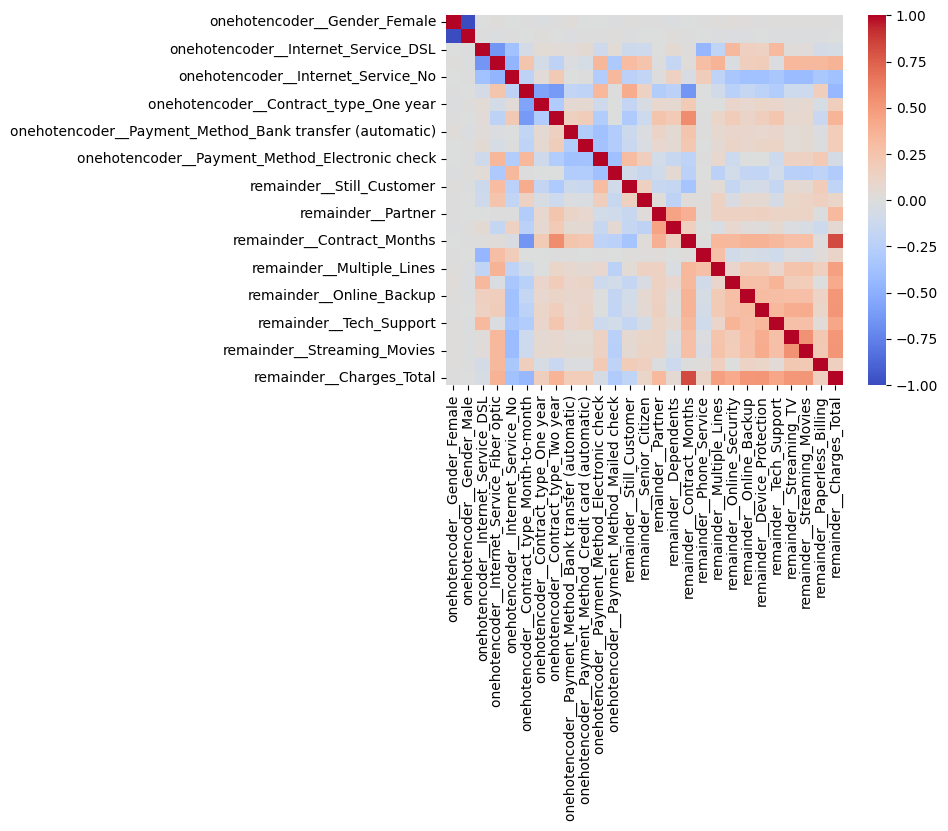

In [14]:
cor =datos.corr()
sns.heatmap(cor,cmap='coolwarm');

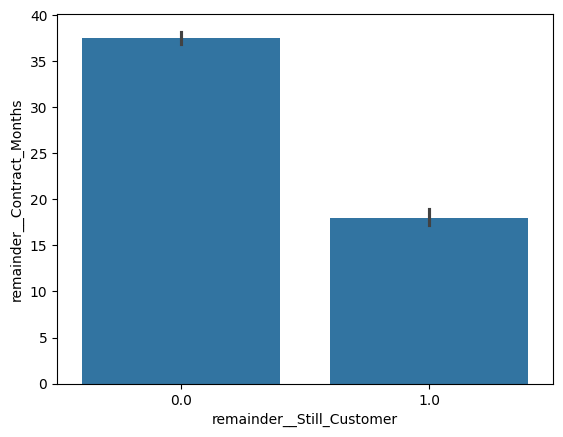

In [15]:
sns.barplot(data=datos,x='remainder__Still_Customer',y='remainder__Contract_Months');


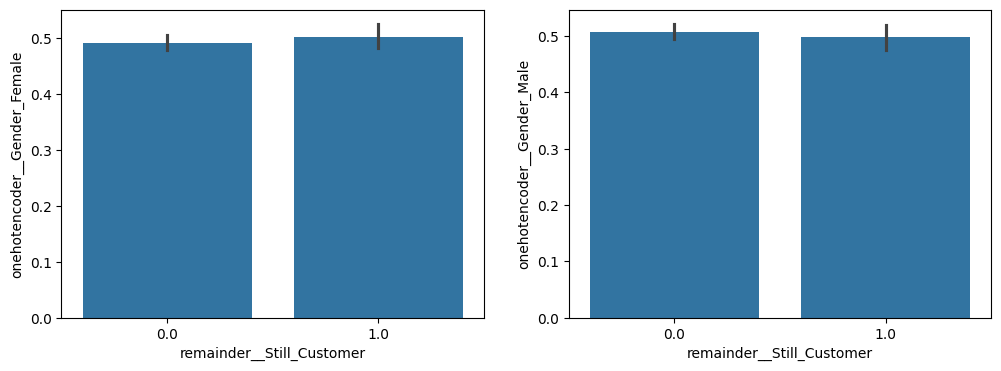

In [16]:
fig, ax = plt.subplots(1,2,figsize = (12,4))
sns.barplot(data=datos,x='remainder__Still_Customer',y='onehotencoder__Gender_Female',ax=ax[0]);
sns.barplot(data=datos,x='remainder__Still_Customer',y='onehotencoder__Gender_Male',ax=ax[1]);

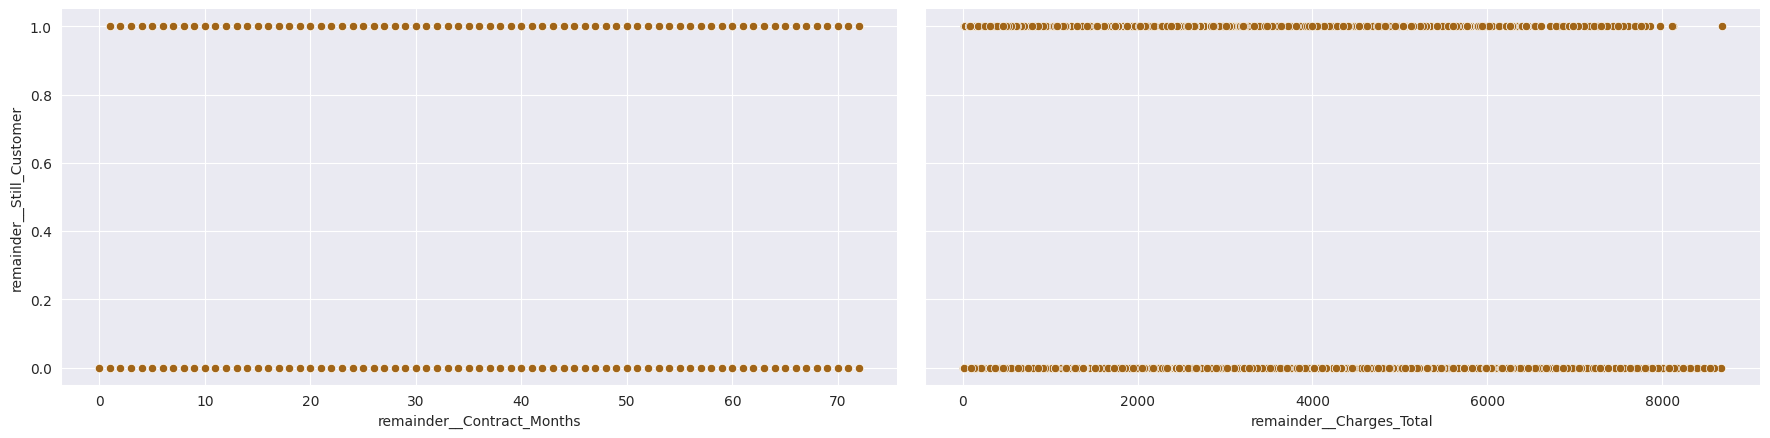

In [17]:
sns.set_palette('BrBG')
# style -> white, dark, whitegrid, darkgrid, ticks
sns.set_style('darkgrid')

ax = sns.pairplot(data=datos,y_vars='remainder__Still_Customer',x_vars = ['remainder__Contract_Months','remainder__Charges_Total']);
ax.figure.set_size_inches(20,5)

ax;

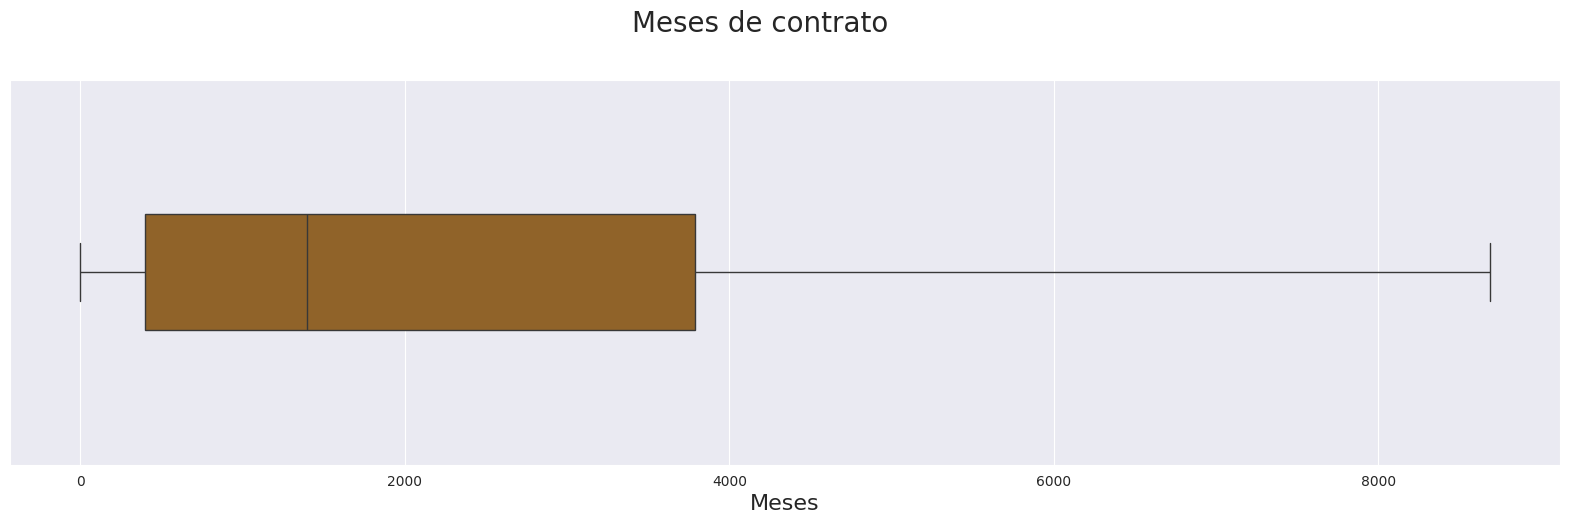

In [18]:
ax = sns.boxplot(data=datos['remainder__Charges_Total'],orient='h',width=0.3)
ax.figure.set_size_inches(20,5)
ax.figure.suptitle('Meses de contrato',fontsize = 20,y=1.02)
ax.set_xlabel('Meses',fontsize = 16)
ax;

## Modelado predictivo

Separar los datos para trabajar con el modelo

In [19]:
from sklearn.model_selection import train_test_split

X = datos.drop(['remainder__Still_Customer'],axis=1)
y = datos['remainder__Still_Customer']

#dividir los datos para prueba
X_train,X_test,y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.3, random_state=10)

## Modelos

Para crear los modelos se considera una validacion cruzada con StratifiedKFold, asi como el balanceo tanto 'undersampling' como 'oversampling' para comparar resultados y usando un pipeline para mejorar resultados tanto el resultado del modelo como el codigo empleado

# Modelo KNN

Este algoritmo se basa en el cálculo de las distancias en los registros de la base de datos debido a esto hay variables que pueden afectar debido al número que tiene y que puede opacar a las variables, por lo que se puede normalizar los datos para poder trabajar mejor con ellos, además del desvalance que también se aplica debido a que tambien puede influir en el modelo.

In [33]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import StratifiedKFold,cross_validate

#estratificacion
skf = StratifiedKFold(n_splits = 5,shuffle = True, random_state=10)

In [21]:
#normalizar
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_test_normalizado = normalizacion.fit_transform(X_test)    #para probar el modelo

In [22]:
pd.DataFrame(X_train_normalizado).head(3) #la matriz queda entre valores 0 y uno dejando todos en la misma escala

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.643538
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.094316
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.211924


In [26]:
# Modelo KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [32]:
#pipeline
pipeline_knn = imbpipeline([('normalizar',normalizacion),('oversample',SMOTE()),('knn',knn)])

cv_resultados = cross_validate(pipeline_knn,X,y,cv=skf,scoring=['accuracy','recall','f1','roc_auc'])
cv_resultados

{'fit_time': array([0.0764904 , 0.06532216, 0.04012585, 0.05580115, 0.03890944]),
 'score_time': array([0.36927104, 0.2506268 , 0.26920462, 0.25707698, 0.25540495]),
 'test_accuracy': array([0.67707594, 0.70546487, 0.68630234, 0.69318182, 0.70099432]),
 'test_recall': array([0.68181818, 0.73529412, 0.70588235, 0.7077748 , 0.71657754]),
 'test_f1': array([0.52849741, 0.56994819, 0.5443299 , 0.55      , 0.56008359]),
 'test_roc_auc': array([0.74325092, 0.77166292, 0.75106823, 0.76432374, 0.7678516 ])}

In [35]:
cv_resultados['test_roc_auc'].mean()

np.float64(0.759631481860062)